In [4]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [5]:
try:
    df = pd.read_csv('StudentPerformanceFactors.csv')
except FileNotFoundError:
    print("Файл не найден")

In [6]:
print("\nПервые 5 строк данных:")
display(df.head())


Первые 5 строк данных:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [7]:
# Корректировка имен колонок для SQL (убираю пробелы и т.п.)
df.columns = [col.strip().replace(' ', '_').replace('-', '_') for col in df.columns]

In [8]:
conn = sqlite3.connect('student_performance.db')
cursor = conn.cursor()
print("База данных 'student_performance.db' создана")

База данных 'student_performance.db' создана


In [9]:
create_table_sql = '''
CREATE TABLE students (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    Hours_Studied INTEGER,
    Attendance INTEGER,
    Sleep_Hours INTEGER,
    Tutoring_Sessions INTEGER,
    Exam_Score INTEGER,
    Motivation_Level TEXT,
    Parental_Involvement TEXT,
    School_Type TEXT
)
'''
cursor.execute(create_table_sql)
conn.commit()
print("Таблица 'students' создана")

Таблица 'students' создана


In [10]:
columns_for_sql = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 
                   'Tutoring_Sessions', 'Exam_Score', 
                   'Motivation_Level', 'Parental_Involvement', 'School_Type']

In [11]:
existing_cols = [col for col in columns_for_sql if col in df.columns]
df[existing_cols].to_sql('students', conn, if_exists='replace', index=False)
print(f"Данные импортированы. Записей в таблице: {pd.read_sql('SELECT COUNT(*) FROM students', conn).iloc[0,0]}")

Данные импортированы. Записей в таблице: 6607


In [12]:
# Запрос 1: допустим, хочу вывести список студентов с высокой успеваемостью (балл >= 80)
query1 = """
SELECT Hours_Studied, Attendance, Exam_Score, Motivation_Level
FROM students
WHERE Exam_Score >= 80
ORDER BY Exam_Score DESC
LIMIT 10;
"""
df_high_scores = pd.read_sql(query1, conn)
print("Топ-10 студентов с баллом не меньше 80:")
display(df_high_scores)

Топ-10 студентов с баллом не меньше 80:


,Hours_Studied,Attendance,Exam_Score,Motivation_Level
0,27,98,101,Low
1,18,89,100,Medium
2,23,83,99,Low
3,14,90,99,Medium
4,28,90,98,Medium
5,28,96,98,High
6,16,83,98,Low
7,15,83,97,Medium
8,21,74,97,Medium
9,25,99,97,Medium


In [14]:
# Запрос 2: хочу вывести недосыпающих студентов (сон меньше 6 часов), которые к тому же занимаются с репетитором
query2 = """
SELECT Sleep_Hours, Tutoring_Sessions, Exam_Score, Attendance
FROM students
WHERE Sleep_Hours < 6 AND Tutoring_Sessions > 2
ORDER BY Exam_Score DESC;
"""
df_sleep_tutor = pd.read_sql(query2, conn)
print("Студенты, спящие меньше 6 ч и у которых больше 2 занятий с репетитором:")
display(df_sleep_tutor.head())


#в развитие на следующие домашки: можно проследить взаимосвязь количества сна, занятий с репетитором и результатом сдачи экзамена

Студенты, спящие меньше 6 ч и у которых больше 2 занятий с репетитором:


,Sleep_Hours,Tutoring_Sessions,Exam_Score,Attendance
0,4,3,100,89
1,4,3,92,88
2,5,6,76,99
3,5,7,75,97
4,5,3,75,98


In [16]:
# Запрос 3: вывожу данные о студентах из частных школ, но с низкой мотивацией
query3 = """
SELECT School_Type, Motivation_Level, Exam_Score, Attendance
FROM students
WHERE School_Type = 'Private' AND Motivation_Level = 'Low'
ORDER BY Exam_Score;
"""
df_private_low_mot = pd.read_sql(query3, conn)
print("Студенты частных школ с низкой мотивацией:")
display(df_private_low_mot.head())

#в развитие на следующие домашки: можно проследить взаимосвязь между уровнем мотивации и результатом экзамена

Студенты частных школ с низкой мотивацией:


,School_Type,Motivation_Level,Exam_Score,Attendance
0,Private,Low,57,64
1,Private,Low,58,69
2,Private,Low,58,67
3,Private,Low,58,73
4,Private,Low,58,64


In [17]:
# Запрос 4: вывожу средние показатели по уровню мотивации
query4 = """
SELECT 
    Motivation_Level,
    COUNT(*) as student_count,
    AVG(Hours_Studied) as avg_study_hours,
    AVG(Attendance) as avg_attendance,
    AVG(Exam_Score) as avg_score,
    MAX(Exam_Score) as max_score,
    MIN(Exam_Score) as min_score
FROM students
GROUP BY Motivation_Level
ORDER BY avg_score DESC;
"""
df_motivation_stats = pd.read_sql(query4, conn)
print("Статистика по уровню мотивации:")
display(df_motivation_stats)

Статистика по уровню мотивации:


,Motivation_Level,student_count,avg_study_hours,avg_attendance,avg_score,max_score,min_score
0,High,1319,19.730099,79.712661,67.704321,98,57
1,Medium,3351,20.082960,80.106535,67.330648,100,55
2,Low,1937,19.956118,79.934435,66.752194,101,57


In [18]:
# Запрос 5: смотрю на влияние вовлеченности родителей
query5 = """
SELECT 
    Parental_Involvement,
    COUNT(*) as student_count,
    AVG(Exam_Score) as avg_score,
    AVG(Attendance) as avg_attendance
FROM students
GROUP BY Parental_Involvement
ORDER BY avg_score DESC;
"""
df_parent_stats = pd.read_sql(query5, conn)
print("Статистика по вовлеченности родителей:")
display(df_parent_stats)

Статистика по вовлеченности родителей:


,Parental_Involvement,student_count,avg_score,avg_attendance
0,High,1908,68.092767,79.948113
1,Medium,3362,67.098156,79.863772
2,Low,1337,66.358265,80.305161


In [19]:
# Запрос 6: смотрю на взаимосвязь учебных часов и оценок 
query6 = """
SELECT 
    CASE 
        WHEN Hours_Studied < 5 THEN '0-4 часов'
        WHEN Hours_Studied < 10 THEN '5-9 часов'
        WHEN Hours_Studied < 15 THEN '10-14 часов'
        ELSE '15+ часов'
    END as study_group,
    COUNT(*) as student_count,
    AVG(Exam_Score) as avg_score,
    AVG(Attendance) as avg_attendance
FROM students
GROUP BY study_group
ORDER BY avg_score DESC;
"""
df_study_groups = pd.read_sql(query6, conn)
print("Статистика по группам учебных часов:")
display(df_study_groups)

Статистика по группам учебных часов:


,study_group,student_count,avg_score,avg_attendance
0,15+ часов,5417,67.787705,79.939450
1,10-14 часов,919,64.989119,80.127312
2,5-9 часов,233,64.034335,80.321888
3,0-4 часов,38,62.500000,79.657895


In [20]:
#Перехожу к визуализации

In [38]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("muted")
fig = plt.figure(figsize=(200, 200))

<Figure size 20000x20000 with 0 Axes>

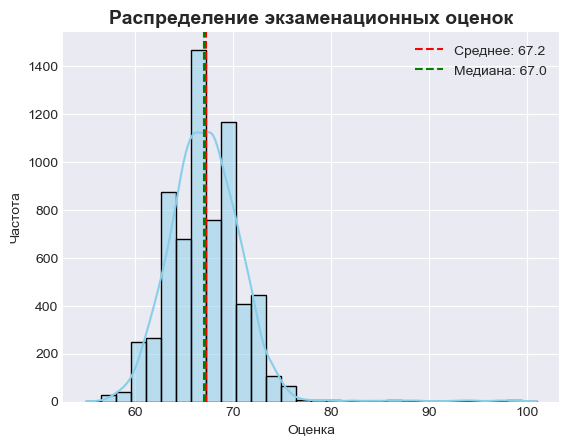

In [47]:

sns.histplot(df['Exam_Score'], bins=30, kde=True, color='skyblue')
plt.axvline(df['Exam_Score'].mean(), color='red', linestyle='--', label=f'Среднее: {df["Exam_Score"].mean():.1f}')
plt.axvline(df['Exam_Score'].median(), color='green', linestyle='--', label=f'Медиана: {df["Exam_Score"].median():.1f}')
plt.title('Распределение экзаменационных оценок', fontsize=14, fontweight='bold')
plt.xlabel('Оценка')
plt.ylabel('Частота')
plt.legend()

#### Распределение близко к нормальному. Среднее и медианное значения почти совпадают (разница в 0.2)

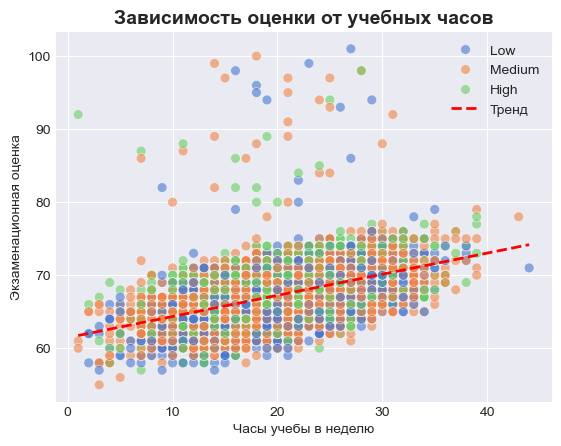

In [46]:

sns.scatterplot(data=df, x='Hours_Studied', y='Exam_Score', hue='Motivation_Level', alpha=0.6, s=50)
# линия тренда
z = np.polyfit(df['Hours_Studied'], df['Exam_Score'], 1)
p = np.poly1d(z)
plt.plot(df['Hours_Studied'].sort_values(), p(df['Hours_Studied'].sort_values()), 
         color='red', linestyle='--', linewidth=2, label='Тренд')
plt.title('Зависимость оценки от учебных часов', fontsize=14, fontweight='bold')
plt.xlabel('Часы учебы в неделю')
plt.ylabel('Экзаменационная оценка')
plt.legend()

#### Можно проследить взаимосвязь в положительном направлении между кол-вом часов учёбы в неделю и оценкой за экзамен, однако также присутствуют аномальные значения. 
#### Цвета точек наблюдений соответствуют уровню мотивации студентов. Основываясь на данном графике нельзя сделать вывод об взаимосвязи между уровнем вовлеченности и результатами/учебными часами


Text(0, 0.5, 'Оценка')

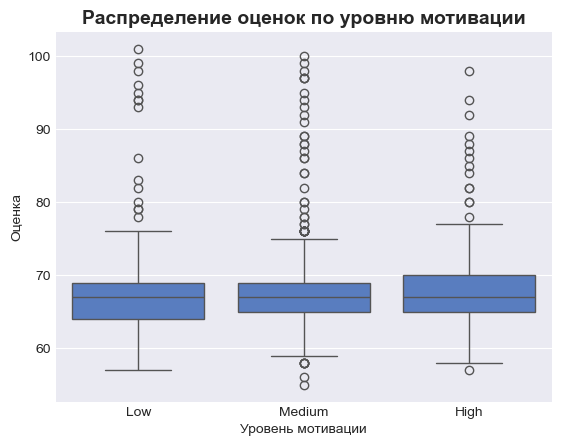

In [45]:

sns.boxplot(data=df, x='Motivation_Level', y='Exam_Score', order=['Low', 'Medium', 'High'])
plt.title('Распределение оценок по уровню мотивации', fontsize=14, fontweight='bold')
plt.xlabel('Уровень мотивации')
plt.ylabel('Оценка')

#### Можно сказать, что, в среднем, оценки за экзамен у студентов с высокой вовлеченностью лучше; имеется большое количество выбросов 

Text(0.5, 1.0, 'Корреляция между числовыми признаками')

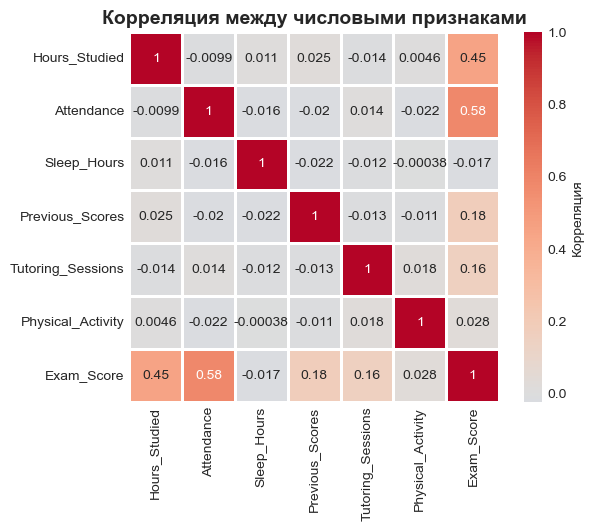

In [43]:

numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={'label': 'Корреляция'})
plt.title('Корреляция между числовыми признаками', fontsize=14, fontweight='bold')

Text(0, 0.5, 'Оценка')

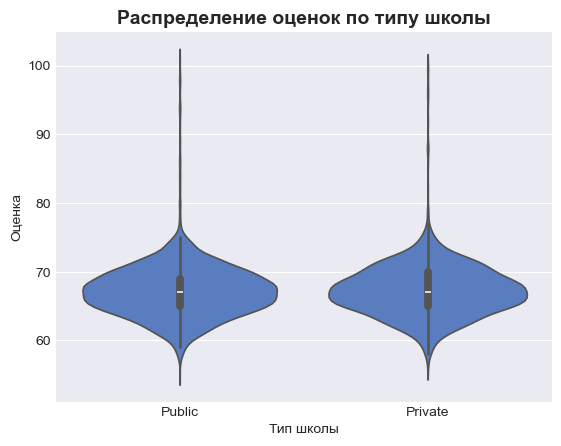

In [48]:
sns.violinplot(data=df, x='School_Type', y='Exam_Score')
plt.title('Распределение оценок по типу школы', fontsize=14, fontweight='bold')
plt.xlabel('Тип школы')
plt.ylabel('Оценка')

In [51]:
conn.close()